In [49]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import scipy.stats

url = "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/soccer-players.csv"
df = pd.read_csv(url)
df.columns


Index(['player_id', 'first_name', 'last_name', 'name', 'last_season',
       'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth',
       'country_of_citizenship', 'date_of_birth', 'sub_position', 'position',
       'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name',
       'image_url', 'url', 'current_club_domestic_competition_id',
       'current_club_name', 'market_value_in_eur',
       'highest_market_value_in_eur'],
      dtype='object')

In [50]:
df.sample(18)


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
6218,72860,NaN,Zezinho,Zezinho,2015,982,zezinho,Brazil,Uruguaiana,Brazil,...,left,175.0,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/zezinho/profil...,PO1,Clube Desportivo Nacional,100000.0,1000000.0
11025,170481,Jean-Daniel,Akpa Akpro,Jean-Daniel Akpa Akpro,2024,398,jean-daniel-akpa-akpro,France,Toulouse,Cote d'Ivoire,...,right,180.0,2025-06-30 00:00:00,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/jean-daniel-ak...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,3500000.0
19073,347610,Aleksandr,Leykin,Aleksandr Leykin,2014,3729,aleksandr-leykin,NaN,NaN,Russia,...,right,185.0,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/aleksandr-leyk...,RU1,Arsenal Tula,NaN,NaN
13612,224774,Cristian,Salvador,Cristian Salvador,2016,2448,cristian-salvador,Spain,Zamora,Spain,...,right,184.0,2024-06-30 00:00:00,YOU FIRST,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/cristian-salva...,ES1,Sporting Gijón,600000.0,700000.0
15491,264176,Liam,Bossin,Liam Bossin,2016,58,liam-bossin,Belgium,Woluwe-Saint-Pierre,Ireland,...,right,190.0,2024-06-30 00:00:00,Grand Stand,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/liam-bossin/pr...,BE1,Royal Sporting Club Anderlecht,400000.0,400000.0
31076,937113,Madi,Monamay,Madi Monamay,2023,15,madi-monamay,NaN,NaN,Belgium,...,right,185.0,2027-06-30 00:00:00,TEAM MONAMAY,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/madi-monamay/p...,L1,Bayer 04 Leverkusen Fußball,NaN,NaN
11911,187962,Manolis,Tzanakakis,Manolis Tzanakakis,2020,6418,manolis-tzanakakis,Greece,Agios Nikolaos,Greece,...,right,178.0,2023-05-31 00:00:00,ACE Management,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/manolis-tzanak...,GR1,Panetolikos Agrinio,200000.0,600000.0
21079,400131,Siebe,Van der Heyden,Siebe Van der Heyden,2024,237,siebe-van-der-heyden,Belgium,Denderleeuw,Belgium,...,left,185.0,2028-06-30 00:00:00,KV Sports Management,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/siebe-van-der-...,ES1,Real Club Deportivo Mallorca S.A.D.,2000000.0,4000000.0
500,5870,Massimo,Donati,Massimo Donati,2017,2999,massimo-donati,Italy,San Vito al Tagliamento,Italy,...,right,189.0,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/massimo-donati...,SC1,Hamilton Academical FC,150000.0,6000000.0
7907,102558,Marco,Verratti,Marco Verratti,2022,583,marco-verratti,Italy,Pescara,Italy,...,right,165.0,2026-06-30 00:00:00,Rafaela Pimenta,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/marco-verratti...,FR1,Paris Saint-Germain Football Club,25000000.0,75000000.0


In [51]:
df = df[["name", "position", "date_of_birth", "height_in_cm"]]

In [52]:
df.head()


,name,position,date_of_birth,height_in_cm
0,Miroslav Klose,Attack,1978-06-09 00:00:00,184.0
1,Roman Weidenfeller,Goalkeeper,1980-08-06 00:00:00,190.0
2,Dimitar Berbatov,Attack,1981-01-30 00:00:00,NaN
3,Lúcio,Defender,1978-05-08 00:00:00,NaN
4,Tom Starke,Goalkeeper,1981-03-18 00:00:00,194.0


In [53]:
df["month"] = pd.to_datetime(df["date_of_birth"]).dt.month
df.head()


,name,position,date_of_birth,height_in_cm,month
0,Miroslav Klose,Attack,1978-06-09 00:00:00,184.0,6.0
1,Roman Weidenfeller,Goalkeeper,1980-08-06 00:00:00,190.0,8.0
2,Dimitar Berbatov,Attack,1981-01-30 00:00:00,NaN,1.0
3,Lúcio,Defender,1978-05-08 00:00:00,NaN,5.0
4,Tom Starke,Goalkeeper,1981-03-18 00:00:00,194.0,3.0


In [54]:
df = df.dropna(subset=["height_in_cm"])
df = df.loc[df["height_in_cm"] > 150]
df.head()

,name,position,date_of_birth,height_in_cm,month
0,Miroslav Klose,Attack,1978-06-09 00:00:00,184.0,6.0
1,Roman Weidenfeller,Goalkeeper,1980-08-06 00:00:00,190.0,8.0
4,Tom Starke,Goalkeeper,1981-03-18 00:00:00,194.0,3.0
7,Tomas Rosicky,Midfield,1980-10-04 00:00:00,179.0,10.0
8,Marc Ziegler,Goalkeeper,1976-06-13 00:00:00,193.0,6.0


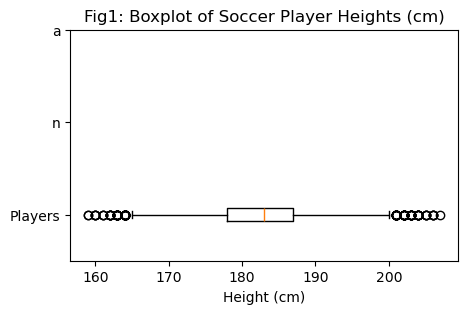

In [55]:
plt.figure(figsize=(5,3))
plt.boxplot(x=df["height_in_cm"], orientation="horizontal")
plt.title("Fig1: Boxplot of Soccer Player Heights (cm)")
plt.xlabel("Height (cm)")
plt.yticks(ticks=[1,2,3], labels=["Players", "n", "a"])
plt.show()

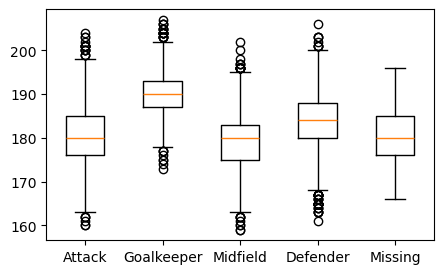

In [56]:
plt.figure(figsize=[5,3])
pos = df["position"].unique()
data = [df.loc[df["position"] == p, "height_in_cm"] for p in pos]
plt.boxplot(x=data)
plt.xticks(ticks=range(1,len(pos)+1), labels = pos)
plt.show()

In [57]:
def boxplots(df: pd.DataFrame, y:str, x:str, title:str, ylabel:str):
    plt.figure(figsize=(5,3))
    hts_box = sns.boxplot(data=df, y=y, x=x)
    hts_box.set(
        title=title,
        ylabel=ylabel) 
    plt.axhline(df[y].mean(), label="Mean", linestyle = "--", color="red")
    plt.legend()
    plt.show()

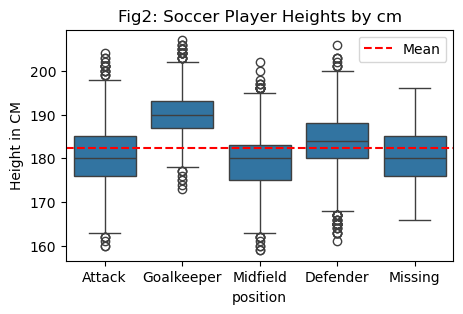

In [58]:
boxplots(df=df, x="position", y="height_in_cm", title="Fig2: Soccer Player Heights by cm", ylabel="Height in CM")

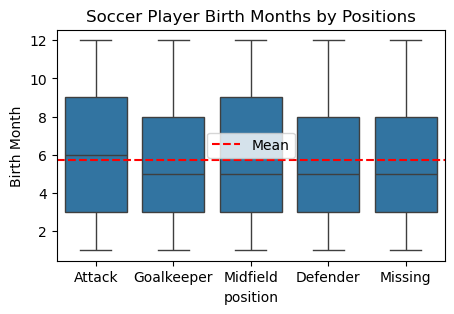

In [59]:
boxplots(df=df, x="position", y="month", title="Soccer Player Birth Months by Positions", ylabel="Birth Month")

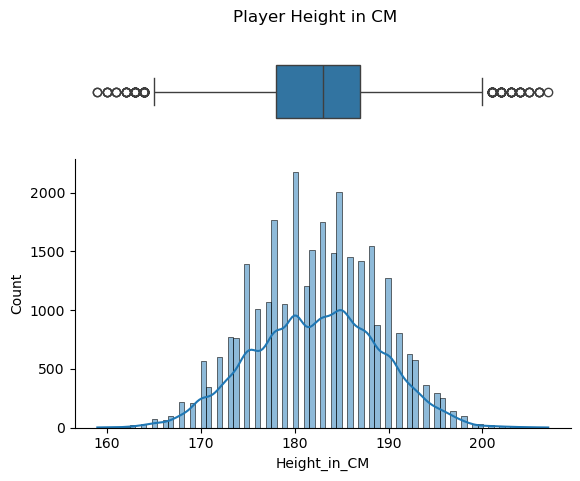

In [60]:
def generate_multiplot(df:pd.DataFrame, col:str, title:str = "", xlabel:str = ""):
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, height_ratios=[2,8])
    box = sns.boxplot(data=df, x=col, ax=ax1)
    hist = sns.histplot(data=df, x=col, ax=ax2, kde = True)
    box.set(yticks=[], xticks=[], xlabel="")
    hist.set(xlabel=xlabel)
    ax1.spines["bottom"].set_visible(False)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    fig.suptitle(title)
    
generate_multiplot(df=df, col="height_in_cm", xlabel="Height_in_CM", title="Player Height in CM")

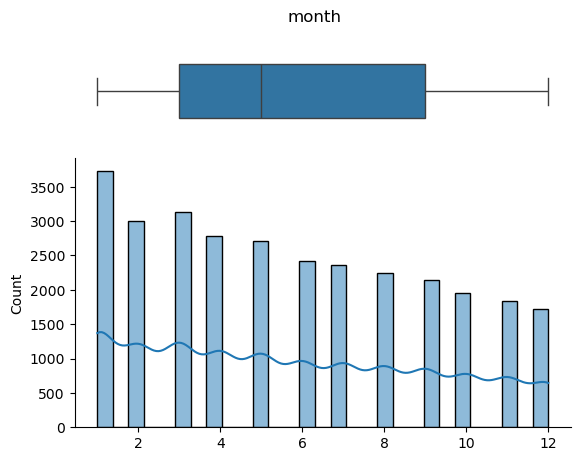

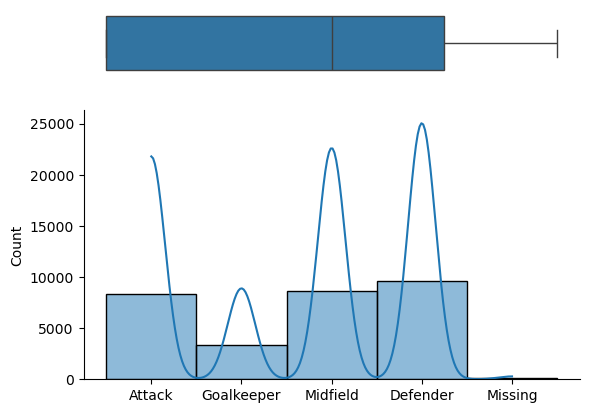

In [62]:
generate_multiplot(df=df, col="month", title = "month")
generate_multiplot(df=df, col="position")